# Testing image statistics using Carcará-X scans

In [1]:
%env PYTHONPATH=/opt/micromamba/envs/sirius/repos/dev-packages:${PYTHONPATH}
import sys
sys.path.insert(0, "/opt/micromamba/envs/sirius/repos/dev-packages/siriuspy/")
sys.path.insert(1, "/home/ABTLUS/arnaldo.filho/repos/cax-scripts")

env: PYTHONPATH=/opt/micromamba/envs/sirius/repos/dev-packages:${PYTHONPATH}


In [2]:
from caxscripts.image_statistics import Histogram2DAnalyzer as H2DA
from caxscripts.scananalysis import data_from_h5_files, files_in_directory
import h5py
import numpy as np
import os
import re
import matplotlib.pyplot as plt

/opt/mamba_files/mamba/envs/sirius/lib/python3.9/site-packages/epics/ca.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Overview of the Analyzer class

In [3]:
print(H2DA.__doc__)
print("#"*80)

Self-contained analysis pipeline for a single 2D histogram.

    Stores the image, bin edges, and intermediate results (moments,
    threshold) as instance attributes.

    Usage::

        # From an existing histogram:
        ana = Histogram2DAnalyzer(hist, xedges, yedges)

        # Or generate a Gaussian test histogram directly:
        ana = Histogram2DAnalyzer.from_gaussian(bins=80, size=200_000)
        ana.add_noise()

        hprm = ana.compute_moments()
        ana.print_stats()
        fig, ax = ana.plot()
        plt.show()

        entropies, bin_edges, thr, nbins = ana.compute_threshold()
        fig = ana.plot_entropy(entropies, bin_edges, thr)
        plt.show()

        hprm = ana.compute_moments(img=ana.img_thresholded)
        hprm = ana.fit()
    
################################################################################


### Files from the TX scans performed @ 2026-03-19

In [4]:
# This way we can easily change the directory

# workdir = "/home/gabriel.amici/testing_data/2026-03-19"
workdir = "/home/arnaldo.filho/Carcara/measurement/2026-03-19"
file_pattern = r"mirror_tx_pass0*"


In [6]:
files = files_in_directory(workdir, file_pattern)
data  = data_from_h5_files(files)

print(f"Loaded {len(files)} files matching pattern '{file_pattern}'"
      f" from '{workdir}'\n Files:")
for f in files:
    print(f" * {f}")


Loaded 11 files matching pattern 'mirror_tx_pass0*' from '/home/arnaldo.filho/Carcara/measurement/2026-03-19'
 Files:
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass01-20260319_135203.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass02-20260319_140127.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass03-20260319_140815.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass04-20260319_141205.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass05-20260319_141544.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass06-20260319_141935.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass07-20260319_142327.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass08-20260319_142753.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass09-20260319_143126.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/

### Sample image

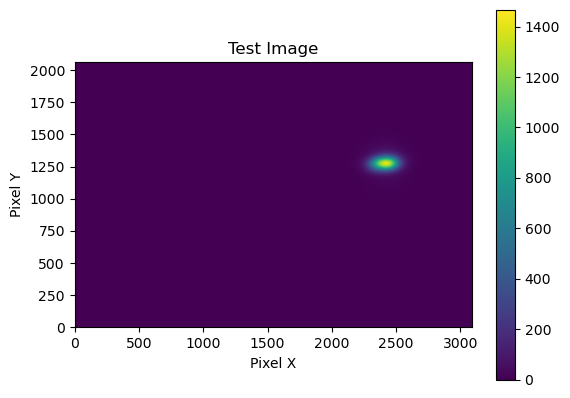

In [7]:
test_img = data['01']['scan-0000']['dvf_B1']['data'].T

# Crude plot to check the image looks correct
plt.imshow(test_img.T, origin='lower')
plt.colorbar()
plt.title("Test Image")
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.show()

In [8]:
# We can now create the analyzer and test it on the image

ana = H2DA(img=test_img,
           xedges=np.arange(test_img.shape[0]+1),
           yedges=np.arange(test_img.shape[1]+1))

There are two main methods for extracting the ditribution parameters
of the image: one is based on computing the moments of the distribution
and using them as the parameters for a biviriate normal distribution;
the other is to perform a nonlinear 2-dimensional gaussian fit over
the image, using the computed moments as an initial guess.

First, we shall look at the calculated moments and the resulting ellipse:

In [9]:
hprm_mom = ana.compute_moments()
ana.print_stats(hprm_mom)

mu         = (2.4095e+03, 1.2689e+03)
sigma x    = 1.0821e+02
sigma y    = 8.8345e+01
xy cov     = 4.4762e+02

principal sigmas:
    sigma minor = 88.05750145074252
    sigma major = 108.44446560402146

theta = -3.0289e+00 rad = -1.7354e+02 deg

cov matrix:
[[11709.54693851   447.6189111 ]
 [  447.6189111   7804.77874338]]


Now let's check the resulting ellipse:

In [10]:
# Global limits for the plot
xlim = (ana.hprm_mom['mux'] - 3.5*ana.hprm_mom['sigx'],
        ana.hprm_mom['mux'] + 3.5*ana.hprm_mom['sigx'])
ylim = (ana.hprm_mom['muy'] - 3.5*ana.hprm_mom['sigy'],
        ana.hprm_mom['muy'] + 3.5*ana.hprm_mom['sigy'])

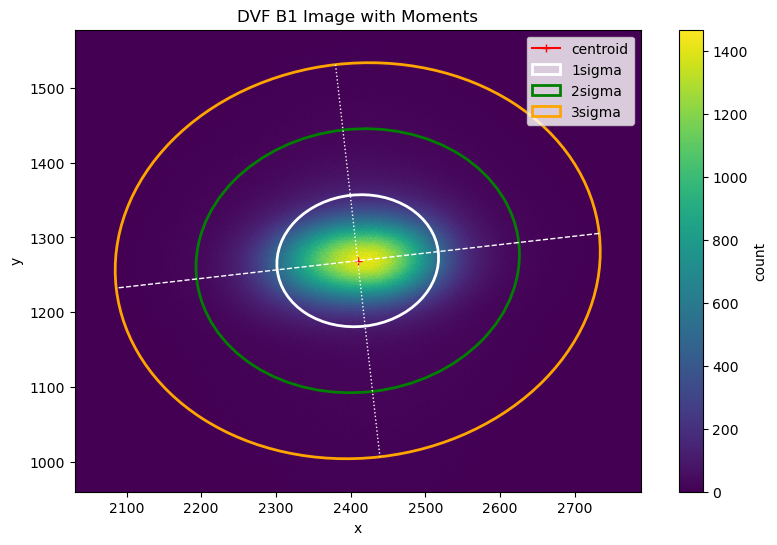

In [11]:
fig, ax = ana.plot(hprm=hprm_mom)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("DVF B1 Image with Moments")
plt.show()


Background noise impedes the moments of this histogram of being an accurate description of the distribution. We can see the difference by fitting a Gaussian distribution using the moments as guesses:

In [12]:
hprm_fit = ana.fit(hprm=hprm_mom, useroi=True)
ana.print_stats(hprm_fit)

mu         = (2.4121e+03, 1.2707e+03)
sigma x    = 7.9802e+01
sigma y    = 4.2371e+01
xy cov     = 1.9061e+02

principal sigmas:
    sigma minor = 42.27720045136444
    sigma major = 79.85197335176773

theta = -3.1000e+00 rad = -1.7762e+02 deg

cov matrix:
[[6368.40690636  190.60715342]
 [ 190.60715342 1795.29241982]]


The fitted ellipse should look more adjusted to the image:

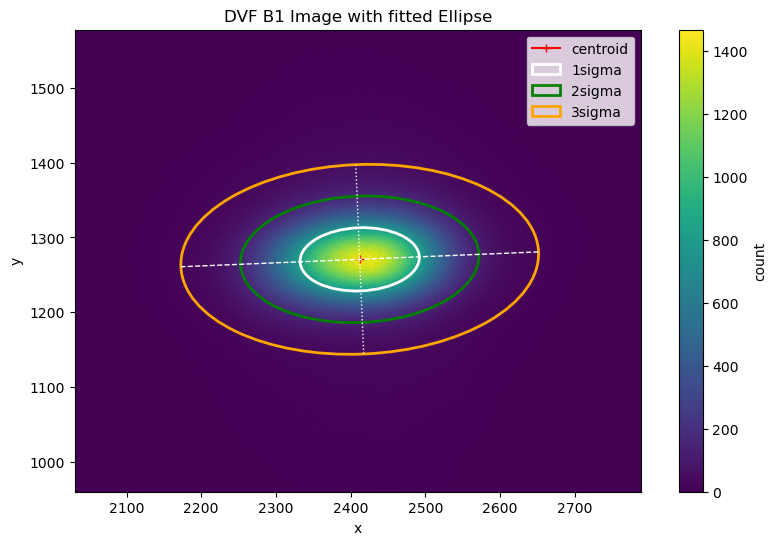

In [13]:
fig, ax = ana.plot(hprm=hprm_fit)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("DVF B1 Image with fitted Ellipse")
plt.show()

The improvement is evident, at the cost of computation time (which can be improved by first defining a ROI inside of which the fitting shall take place).

Now we shall analyze the impact of the background noise by first computing the Kapur entropy threshold:

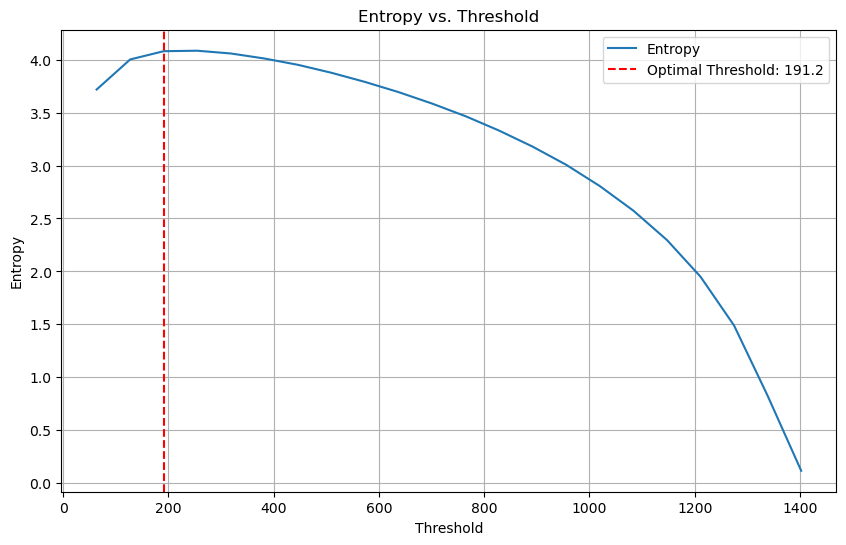

In [14]:
entropies, bin_edges, optimal_threshold, _ = ana.compute_threshold()
ana.plot_entropy(entropies, bin_edges, optimal_threshold)
plt.show()

The use of `compute_threshold` yelds a new class attribute named `image_thresholded`, which we can plot to check the discarded area:

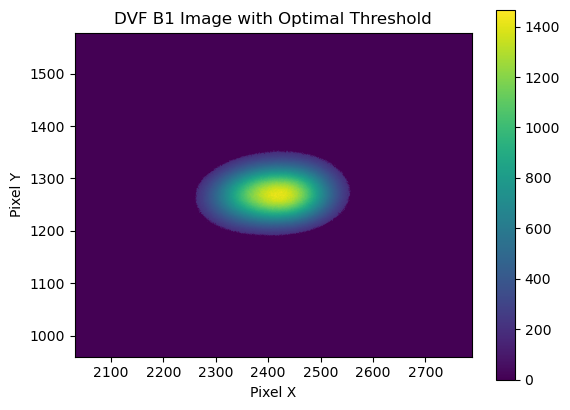

In [15]:
# We can also plot the image with the optimal threshold
plt.imshow(ana.img_thresholded.T, origin='lower')
plt.colorbar()
plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("DVF B1 Image with Optimal Threshold")
plt.show()

Now we can define a new Analyzer whose image is just the foreground of `ana_scan.img`

In [16]:
anath = H2DA(img=ana.img_thresholded,
             xedges=ana.xedges,
             yedges=ana.yedges)

In [17]:
thrs_hprm_mom = anath.compute_moments()
anath.print_stats(thrs_hprm_mom)

mu         = (2.4110e+03, 1.2709e+03)
sigma x    = 6.1648e+01
sigma y    = 3.2807e+01
xy cov     = 1.2380e+02

principal sigmas:
    sigma minor = 32.72177830684085
    sigma major = 61.693547193265246

theta = -3.0963e+00 rad = -1.7740e+02 deg

cov matrix:
[[3800.47911115  123.80097984]
 [ 123.80097984 1076.32942969]]


Comparing with the fitted parameters of `ana_scan`:

In [18]:
ana.print_stats(hprm_fit)

mu         = (2.4121e+03, 1.2707e+03)
sigma x    = 7.9802e+01
sigma y    = 4.2371e+01
xy cov     = 1.9061e+02

principal sigmas:
    sigma minor = 42.27720045136444
    sigma major = 79.85197335176773

theta = -3.1000e+00 rad = -1.7762e+02 deg

cov matrix:
[[6368.40690636  190.60715342]
 [ 190.60715342 1795.29241982]]


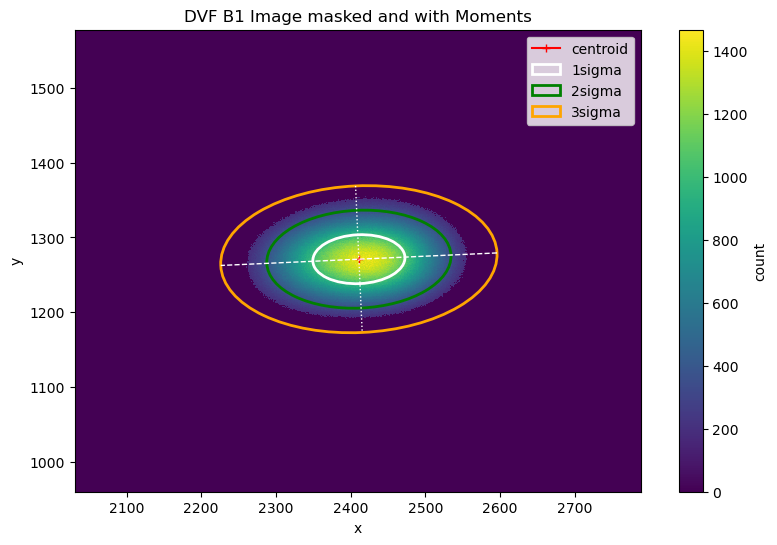

In [19]:
fig, ax = anath.plot(hprm=thrs_hprm_mom)
ax.set_title("DVF B1 Image masked and with Moments")
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()

The result is more similar to the fitted parameters of the original `ana_scan`, but sigmas are subestimated: threshold value seems to be high, eliminating parts of the light halo around the beam image.

Finally, we can also fit a 2D Gaussian over the thresholded image:

In [20]:
thrs_hprm_fit = anath.fit(hprm=thrs_hprm_mom)
anath.print_stats(thrs_hprm_fit)

mu         = (2.4124e+03, 1.2706e+03)
sigma x    = 6.8395e+01
sigma y    = 3.5640e+01
xy cov     = 1.3423e+02

principal sigmas:
    sigma minor = 35.56573732570963
    sigma major = 68.43337568561395

theta = -3.1023e+00 rad = -1.7775e+02 deg

cov matrix:
[[4677.84781627  134.22797499]
 [ 134.22797499 1270.20076298]]


This is still underestimated... the plot is informative:

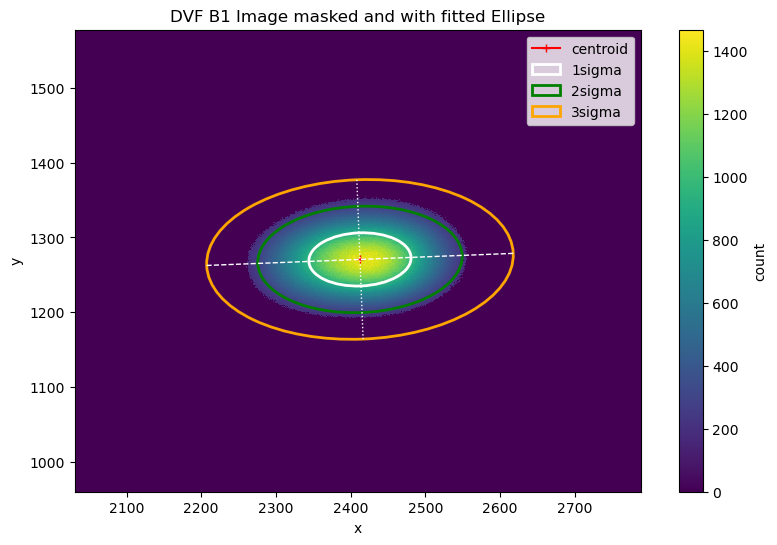

In [21]:
fig, ax = anath.plot(hprm=thrs_hprm_fit)
ax.set_title("DVF B1 Image masked and with fitted Ellipse")
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()

To better visualize the differences, we can make a general plot:

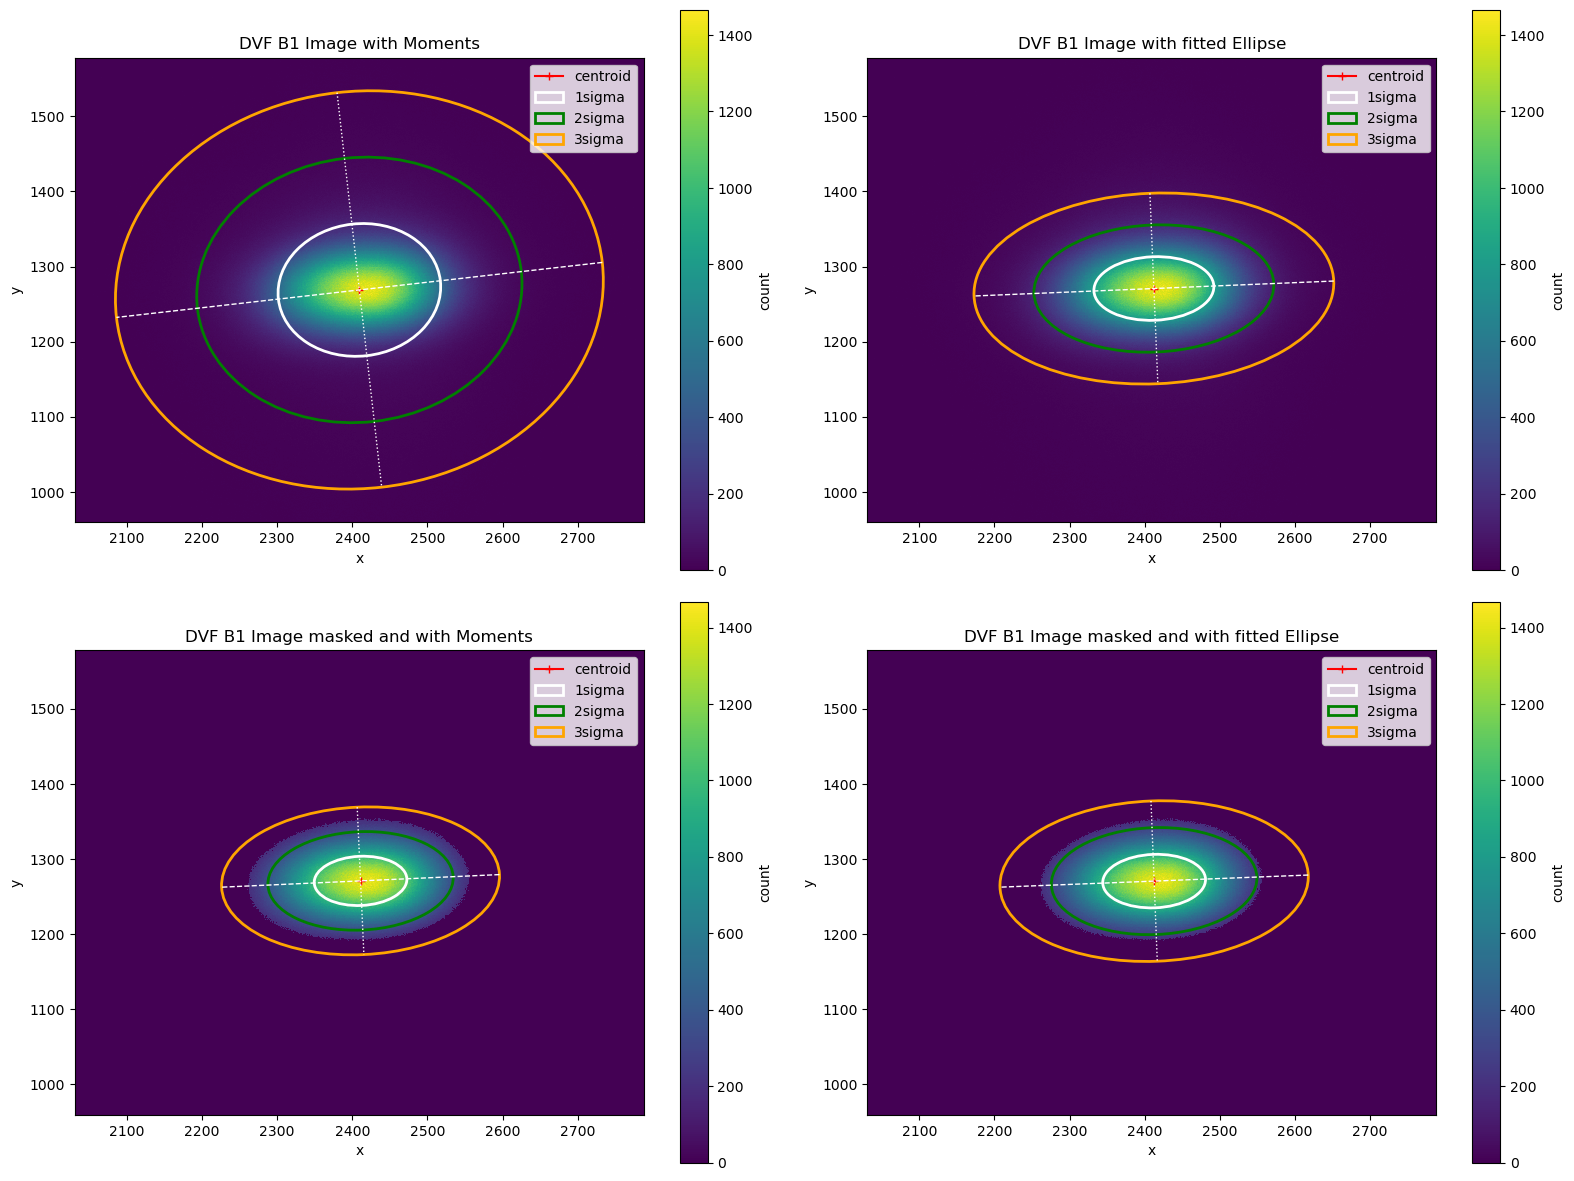

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

ana.plot(hprm=hprm_mom, fig=fig, ax=axs[0, 0])
axs[0, 0].set_title("DVF B1 Image with Moments")

ana.plot(hprm=hprm_fit, fig=fig, ax=axs[0, 1])
axs[0, 1].set_title("DVF B1 Image with fitted Ellipse")

anath.plot(hprm=thrs_hprm_mom, fig=fig, ax=axs[1, 0])
axs[1, 0].set_title("DVF B1 Image masked and with Moments")

anath.plot(hprm=thrs_hprm_fit, fig=fig, ax=axs[1, 1])
axs[1, 1].set_title("DVF B1 Image masked and with fitted Ellipse")

for i in range(2):
    for j in range(2):
        axs[i, j].set_xlim(xlim)
        axs[i, j].set_ylim(ylim)

plt.tight_layout()
plt.show()

#### Plot images and their projections.

Function to plot image and its projections.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_projections(ana, img, hprm, xlim, ylim, title=None):
    """Plot the image with the fitted ellipse and respective projections.

    Arguments:
        ana  : Histogram2DAnalyzer instance with the image and parameters.
        img  : image data to plot.
        hprm : dictionary of parameters to plot the ellipse.
        xlim : horizontal limits for the main image plot.
        ylim : vertical limits for the main image plot.
        title : title for the main image plot.
    """
    fig, ax0 = plt.subplots(figsize=(14, 6))

    divider = make_axes_locatable(ax0)
    axb = divider.append_axes("bottom", size="25%", pad=0.3, sharex=ax0)
    axr = divider.append_axes("right", size="25%", pad=0.3, sharey=ax0)

    # Plot the main image with the ellipses (no colorbar to avoid displacement).
    ana.plot(hprm=hprm, fig=fig, ax=ax0, colorbar=False)
    ax0.set_xlim(xlim)
    ax0.set_ylim(ylim)
    if title is not None:
        ax0.set_title(title)

    # Suppress redundant tick labels
    ax0.tick_params(labelbottom=False)
    axr.tick_params(labelleft=False)

    xproj = np.sum(img, axis=0)
    py = np.arange(len(xproj))
    axr.plot(xproj, py, drawstyle='steps-post')

    # axr.axhline(hprm['muy'], color='red', linestyle='--', label='Center Y')

    yproj = np.sum(img, axis=1)
    axb.plot(yproj, drawstyle='steps-post')

    axb.grid(True)
    axr.grid(True)


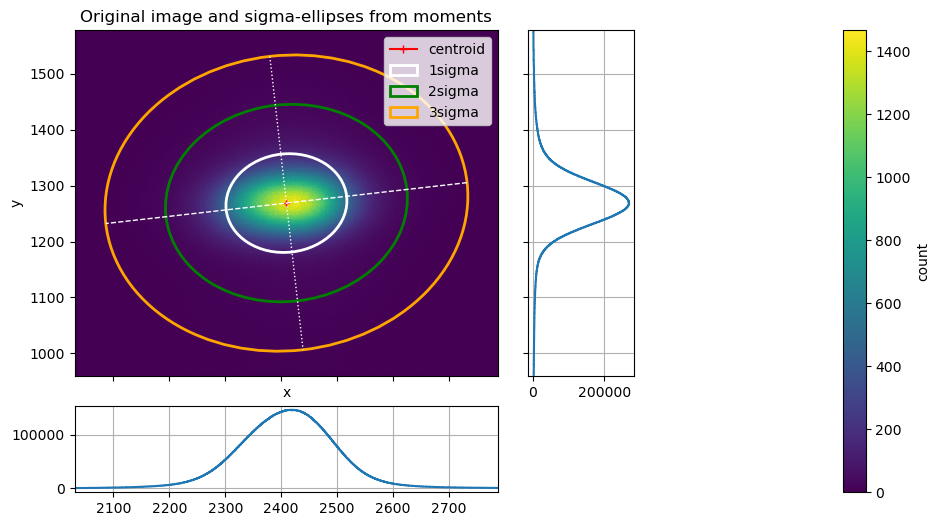

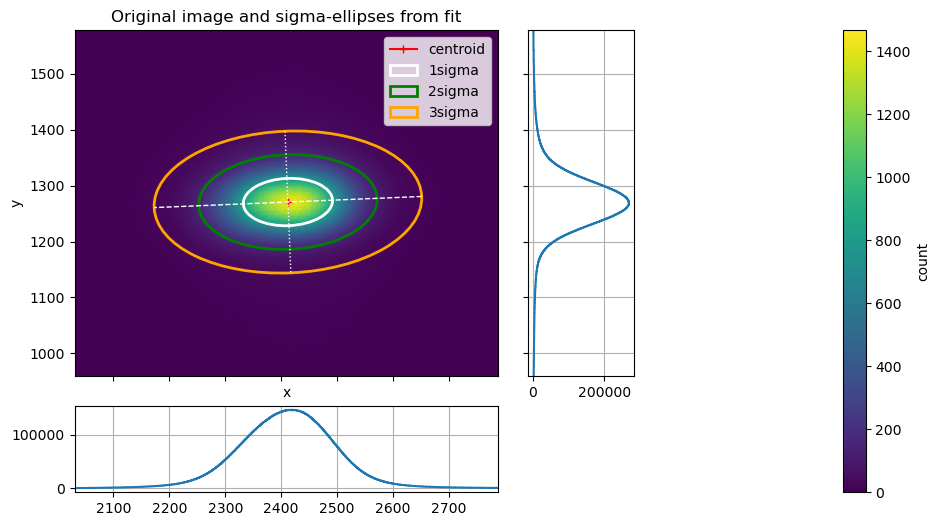

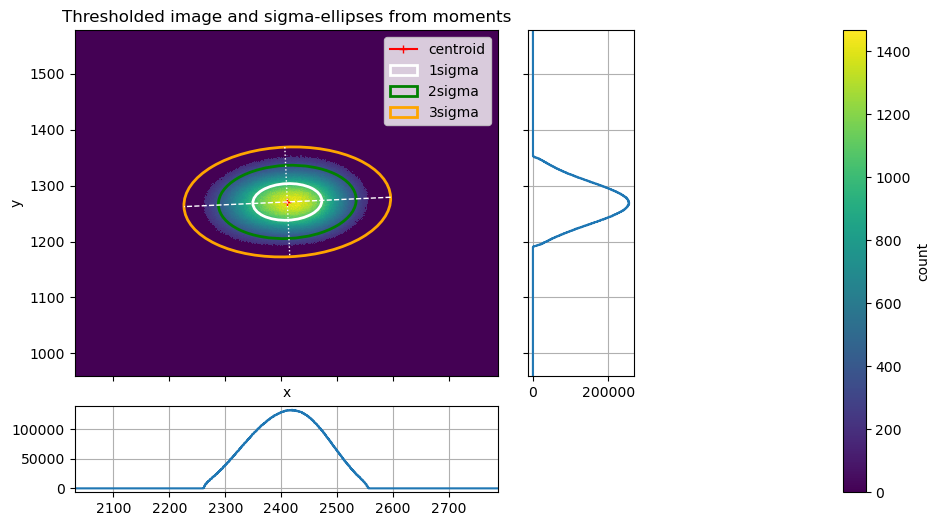

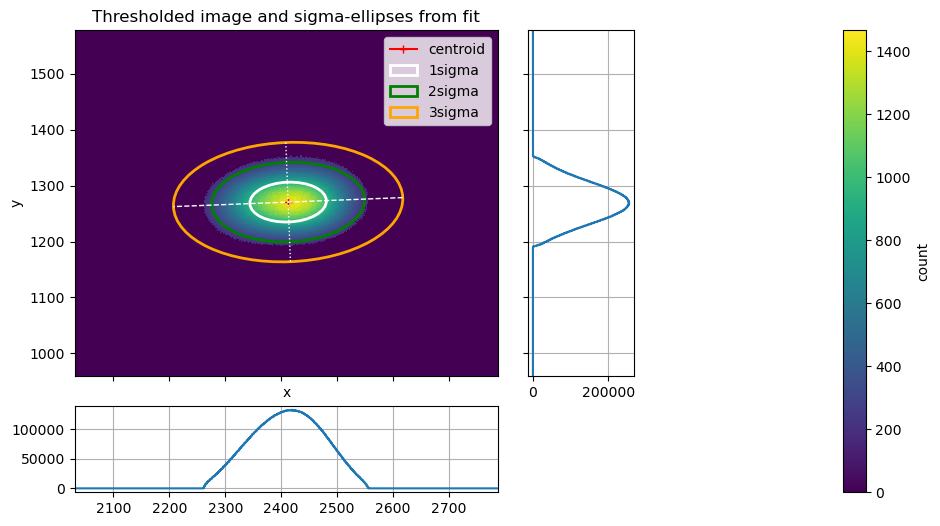

In [24]:
title = "Original image and sigma-ellipses from moments"
plot_projections(ana, ana.img, hprm_mom, xlim, ylim, title=title)

title = "Original image and sigma-ellipses from fit"
plot_projections(ana, ana.img, hprm_fit, xlim, ylim, title=title)

title = "Thresholded image and sigma-ellipses from moments"
plot_projections(anath, anath.img, thrs_hprm_mom, xlim, ylim, title=title)

title = "Thresholded image and sigma-ellipses from fit"
plot_projections(anath, anath.img, thrs_hprm_fit, xlim, ylim, title=title)

plt.show()


And we can overview all the parameters:

In [25]:
# The table of results can be printed using the tabulate library for better formatting,
# install it if you don't have it already:

%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [26]:
from tabulate import tabulate

# Collect all analysis results
results = [
    ["Moments",
     hprm_mom['mux'],
     hprm_mom['muy'],
     hprm_mom['sig_major'],
     hprm_mom['sig_minor'],
     hprm_mom['theta'],
     hprm_mom['cov'][0, 1]],
    ["Fitted Ellipse",
     hprm_fit['mux'],
     hprm_fit['muy'],
     hprm_fit['sig_major'],
     hprm_fit['sig_minor'],
     hprm_fit['theta'],
     hprm_fit['cov'][0, 1]],
    ["Thresholded Moments",
     thrs_hprm_mom['mux'],
     thrs_hprm_mom['muy'],
     thrs_hprm_mom['sig_major'],
     thrs_hprm_mom['sig_minor'],
     thrs_hprm_mom['theta'],
     thrs_hprm_mom['cov'][0, 1]],
    ["Thresholded Fitted Ellipse",
     thrs_hprm_fit['mux'],
     thrs_hprm_fit['muy'],
     thrs_hprm_fit['sig_major'],
     thrs_hprm_fit['sig_minor'],
     thrs_hprm_fit['theta'],
     thrs_hprm_fit['cov'][0, 1]],
]

headers = [
    "Method",
    "Mux",
    "Muy",
    "Sigma Major",
    "Sigma Minor",
    "Theta (rad)",
    "Cov(X,Y)"
    ]

# Format floats to 2 decimal places
table_data = [
    [row[0]] + [f"{val:.2f}" for val in row[1:]]
    for row in results
    ]

print("Summary of statistics:")
print("\n" + tabulate(table_data, headers=headers, tablefmt="grid"))

Summary of statistics:

+----------------------------+---------+---------+---------------+---------------+---------------+------------+
| Method                     |     Mux |     Muy |   Sigma Major |   Sigma Minor |   Theta (rad) |   Cov(X,Y) |
+============================+=========+=========+===============+===============+===============+============+
| Moments                    | 2409.45 | 1268.86 |        108.44 |         88.06 |         -3.03 |     447.62 |
+----------------------------+---------+---------+---------------+---------------+---------------+------------+
| Fitted Ellipse             | 2412.12 | 1270.73 |         79.85 |         42.28 |         -3.1  |     190.61 |
+----------------------------+---------+---------+---------------+---------------+---------------+------------+
| Thresholded Moments        | 2411    | 1270.91 |         61.69 |         32.72 |         -3.1  |     123.8  |
+----------------------------+---------+---------+---------------+--------------